Based on https://github.com/XENON1T/LowER/blob/master/LowER/solarnu.py

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy import stats
from multihist import Hist1d

In [2]:
params = {
    'xtick.direction' : 'in',
    'ytick.direction' : 'in',
    'font.family' : 'serif',
    'font.size' : 15,
    'xtick.labelsize' : 15,
    'ytick.labelsize' : 15,
    'xtick.major.size' : 8,
    'ytick.major.size' : 8,
    'xtick.major.width' : 1.5,
    'ytick.major.width' : 1.5,
    'axes.linewidth' : 1.5,
    'axes.labelsize' : 17
}

plt.rcParams.update(params)
# plt.rc('text', usetex=True)

In [3]:
class Constants:
    G_f = 1.166e-17# keV^{-2}
    m_e = 511  # keV
    s_w = np.sqrt(0.232)  # PDG
    N_a = 6.02e23
    hbar = 6.58e-19  # keV*s
    c = 3e10  # cm/s
    alpha = 1 / 137
    mu_b = np.sqrt(4 * np.pi * alpha) / (2 * m_e)  # keV^{-1}
    
class XeShell:
    # (n_electron, energy [keV])
    shells = [(54, 34.561),
              (52, 5.453),
              (50, 5.107),
              (47 ,4.786),
              (44, 1.148),
              (42, 1.002),
              (39, 0.941),
              (36, 0.689),
              (31, 0.676),
              (26, 0.213),
              (24, 0.147),
              (21, 0.145),
              (18, 0.070),
              (13, 0.068),
              (8, 0.023),
              (6, 0.013),
              (3, 0.012)
              ]
    k_shell = shells[0][1]
    outer_shell = shells[-1][1]

    def __init__(self):
        pass

    def num_accessible(self, E):
        if hasattr(E, '__len__'):
            return np.array([self.num_accessible(e) for e in E])
        if E >= self.k_shell:
            return 54
        elif E < self.outer_shell:
            return 0
        else:
            next_shell = self.k_shell
            for n, e in self.shells:
                if e < E <= next_shell:
                    return n
            return 3

C = Constants()
Xe = XeShell()

In [4]:
neutrino_e = {
    'label'	: r"$\nu_e$",
    'gv'	: 2*C.s_w ** 2 + 1/2,
    'ga'	: 1/2
}
neutrino_mu_tau = {
    'label'	: r"$\nu_{\mu,\tau}$",
    'gv'	: 2*C.s_w ** 2 - 1/2,
    'ga'	: -1/2
}

anti_neutrino_e = {
    'label'	: r"$\bar{\nu}_e$",
    'gv'	: 2*C.s_w ** 2 + 1/2,
    'ga'	: -1/2
}
anti_neutrino_mu_tau = {
    'label'	: r"$\bar{\nu}_{\mu,\tau}$",
    'gv'	: 2*C.s_w ** 2 - 1/2,
    'ga'	: 1/2
}

neutrinos = [neutrino_e, neutrino_mu_tau, anti_neutrino_e, anti_neutrino_mu_tau]

# Standard model CC-interaction spectrum

In [5]:
def max_recoil_energy(Enu):
    # in keV
    return 2*Enu**2 / (C.m_e + 2*Enu)

def min_Enu(Er):
    # minimum neutrino energy in keV
    return 0.5 * (Er + np.sqrt(Er**2 + 2*Er*C.m_e))

def SM_diff_xsec(Er, Enu, nu, stepping=False):
    """returns Standard Model differential cross section in units of cm^2/keV"""
    # break into a few parts for readability

    a = C.G_f ** 2 * C.m_e / (2 * np.pi)
    b = (nu['gv']+nu['ga'])**2
    c = (nu['gv']-nu['ga'])**2 * (1-Er/Enu) ** 2
    d = (nu['gv']**2 - nu['ga']**2)*C.m_e*Er/Enu**2

    si_corr = (C.hbar * C.c) ** 2
    stepping_corr = Xe.num_accessible(Er) / 54 if stepping else 1.0
 
    ret = a * (b + c - d) * si_corr * stepping_corr
   
    return ret * (Enu > min_Enu(Er)) * (Er <= max_recoil_energy(Enu)) 
        
class SolarNu:

    def dRdE_SM(self, Er, E_nu, nu, stepping=False, p=None):
        """SM differential rate, in units events/ton/keV"""
        # so that it can handle arrays
        if hasattr(Er, "__len__"):
            return np.array([self.dRdE_SM(E, E_nu, nu, stepping=stepping, p=p) for E in Er])

        # needs to be cm^2/keV

        xsec = SM_diff_xsec(Er, E_nu, nu, stepping=stepping)
        # f(_ev)=F*delta(_ev), so no-integration         

        return xsec * (C.N_a/131.3) * 54 * 1e6

In [8]:
Es = np.linspace(0, 250, 10000)

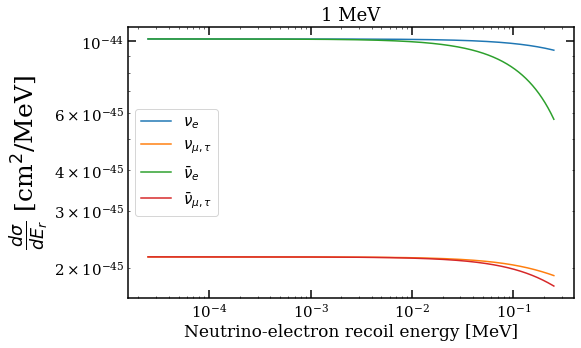

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(8,5))
for neu in neutrinos:
    rates = [SM_diff_xsec(x, 1000, neu) * 1000 for x in Es] 
    plt.plot(Es[1:]/1000, rates[1:], label=neu['label'])
ax.set_title("1 MeV")
ax.set_xlabel("Neutrino-electron recoil energy [MeV]")
ax.set_ylabel(r"$\frac{d\sigma}{dE_r}$ [cm$^{2}$/MeV]", fontsize = 25)
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.legend()
plt.yscale('log')
plt.xscale('log')
#plt.ylim(1e-47,1e-43)

plt.show()

In [10]:
nu = SolarNu()

In [11]:
stepping = True

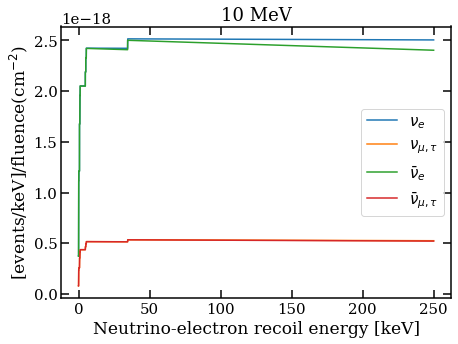

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(7,5))
for neu in neutrinos:
    rates = nu.dRdE_SM(Es, 10000.0, neu, stepping=stepping)
    plt.plot(Es[1:], rates[1:], label=neu['label'])
ax.set_title("10 MeV")
ax.set_xlabel("Neutrino-electron recoil energy [keV]")
ax.set_ylabel(r"[events/keV]/fluence(cm$^{-2}$)")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.legend()
plt.show()

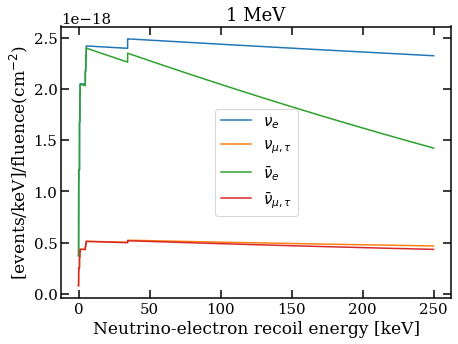

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(7,5))
for neu in neutrinos:
    rates = nu.dRdE_SM(Es, 1000.0, neu, stepping=stepping)
    plt.plot(Es[1:], rates[1:], label=neu['label'])
ax.set_title("1 MeV")
ax.set_xlabel("Neutrino-electron recoil energy [keV]")
ax.set_ylabel(r"[events/keV]/fluence(cm$^{-2}$)")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.legend()
plt.show()

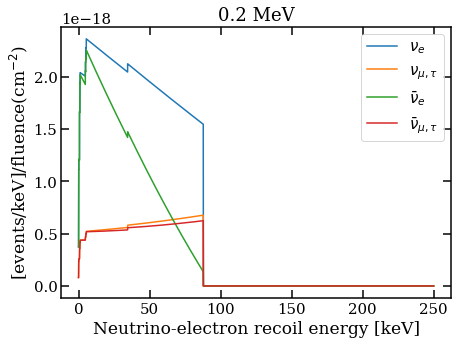

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(7,5))
for neu in neutrinos:
    rates = nu.dRdE_SM(Es, 200.0, neu, stepping=stepping)
    plt.plot(Es[1:], rates[1:], label=neu['label'])
ax.set_title("0.2 MeV")
ax.set_xlabel("Neutrino-electron recoil energy [keV]")
ax.set_ylabel(r"[events/keV]/fluence(cm$^{-2}$)")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.legend()
plt.show()

# Acceptance

ER_efficiency.csv is created using https://github.com/XENON1T/LowER/blob/master/analysis/paper/signal_models.ipynb

where 'Energy' = xs = np.linspace(0, 210, 1000) and 'Efficiency' = eff = efficiency(xs, errors=True, sciencerun='sr1')

In [19]:
acc_data = pd.read_csv('/depot/darkmatter/data/jupyterhub/Riya/ER_efficiency.csv')
accept = acc_data['Efficiency']
energy_ER = acc_data['Energy']
accept_ER = interp1d(energy_ER, accept, bounds_error=False, fill_value=0, kind='linear')

No handles with labels found to put in legend.


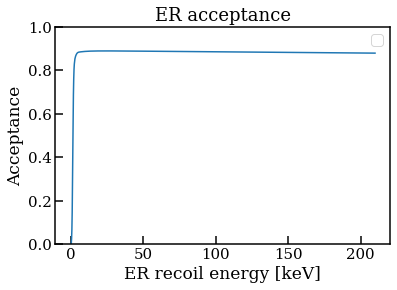

In [20]:
plt.plot(energy_ER, accept_ER(energy_ER))
plt.xlabel('ER recoil energy [keV]')
plt.ylabel('Acceptance')
plt.title("ER acceptance")
plt.ylim(0,1)
plt.legend()
plt.show()

In [21]:
#taken from https://github.com/XENON1T/LowER/blob/master/LowER/ces.py
ER_min = 1 # keV
ER_max = 210 #keV

cutoff = (ER_min, ER_max)

def energy_res(energy, a=30.98, b=0.37, thresh=0):
    return ((np.sqrt(energy) * a + energy * b) * (energy > thresh))/100

def edges(centers):
    diff = np.diff(centers)
    return np.linspace(centers[0]-0.5*diff[0], centers[-1]+0.5*diff[-1],
                       len(centers)+1)

def clip(hist, cut=cutoff):
    # remove all bin_centers whose right/left edge is outside cutoff
    left_edges = hist.bin_edges[:-1]
    right_edges = hist.bin_edges[1:]
    i = np.where((cut[0] < right_edges) & (left_edges < cut[1]))
    bins = hist.bin_centers[i]
    h = Hist1d.from_histogram(hist.histogram[i], bin_edges=edges(bins))
    return h

def smear_array(Es, rate, acceptance, fm, bins=np.linspace(0, 210, 1000)):
    idx = np.where(Es > 0)
    Es = Es[idx]
    rate = rate[idx]
    smeared_x = 0.5*(bins[1:] + bins[:-1])
    smeared = np.zeros_like(smeared_x)
    widths = np.diff(edges(Es))
    for i, E in enumerate(smeared_x):
        probs = stats.norm.pdf(E, loc=Es, scale=energy_res(Es))*widths
        smeared[i] = np.sum(probs * rate) * acceptance(E) * fm
    return clip(Hist1d.from_histogram(smeared, bin_edges=bins))

# Events in our detector at fixed Energy

In [22]:
fm_ER = 1.042


No handles with labels found to put in legend.


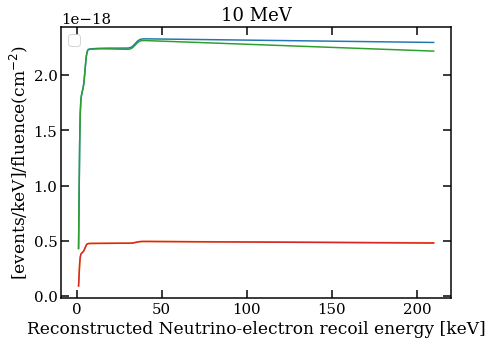

In [23]:
fig, ax = plt.subplots(1, 1, figsize=(7,5))
for neu in neutrinos:
    rates = nu.dRdE_SM(Es, 10000.0, neu, stepping=stepping)
    rate_interp = interp1d(Es, rates , bounds_error=False, fill_value=0)
    nu_smeared = smear_array(Es, rate_interp(Es), accept_ER, fm_ER, bins=np.linspace(1, 210,630))
    #nu_smeared.plot(log_label=neu['label'])
    plt.plot(nu_smeared.bin_centers, nu_smeared.histogram)
    #plt.plot(energy_ER, rates, label=neu['label'])
ax.set_title("10 MeV")
ax.set_xlabel("Reconstructed Neutrino-electron recoil energy [keV]")
ax.set_ylabel(r"[events/keV]/fluence(cm$^{-2}$)")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.legend()

plt.show()

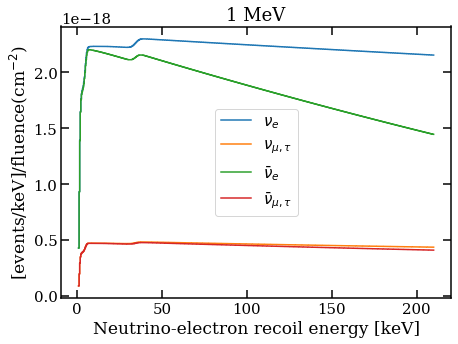

In [24]:
fig, ax = plt.subplots(1, 1, figsize=(7,5))
for neu in neutrinos:
    rates = nu.dRdE_SM(Es, 1000.0, neu, stepping=stepping)
    rate_interp = interp1d(Es, rates , bounds_error=False, fill_value=0)
    nu_smeared = smear_array(Es, rate_interp(Es), accept_ER, fm_ER, bins=np.linspace(1, 210,630))
    nu_smeared.plot(label=neu['label'])
ax.set_title("1 MeV")
ax.set_xlabel("Neutrino-electron recoil energy [keV]")
ax.set_ylabel(r"[events/keV]/fluence(cm$^{-2}$)")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.legend()

plt.show()

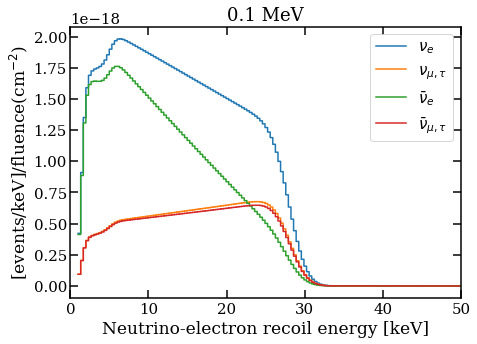

In [25]:
fig, ax = plt.subplots(1, 1, figsize=(7,5))
for neu in neutrinos:
    rates = nu.dRdE_SM(Es, 100.0, neu, stepping=stepping)
    rate_interp = interp1d(Es, rates , bounds_error=False, fill_value=0)
    nu_smeared = smear_array(Es, rate_interp(Es), accept_ER, fm_ER, bins=np.linspace(1, 210,630))
    nu_smeared.plot(label=neu['label'])
ax.set_title("0.1 MeV")
ax.set_xlabel("Neutrino-electron recoil energy [keV]")
ax.set_ylabel(r"[events/keV]/fluence(cm$^{-2}$)")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.legend()
plt.xlim(0,50)
plt.show()

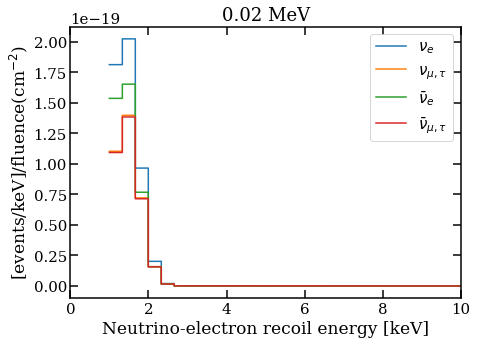

In [26]:
fig, ax = plt.subplots(1, 1, figsize=(7,5))
for neu in neutrinos:
    rates = nu.dRdE_SM(Es, 20.0, neu, stepping=stepping)
    rate_interp = interp1d(Es, rates , bounds_error=False, fill_value=0)
    nu_smeared = smear_array(Es, rate_interp(Es), accept_ER, fm_ER, bins=np.linspace(1, 210,630))
    nu_smeared.plot(label=neu['label'])
ax.set_title("0.02 MeV")
ax.set_xlabel("Neutrino-electron recoil energy [keV]")
ax.set_ylabel(r"[events/keV]/fluence(cm$^{-2}$)")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.legend()
plt.xlim(0,10)
plt.show()

# Events in detector for neutrino energies

In [27]:
#Threshold of our detector
min_Enu(ER_min)

16.492185591719476

In [28]:
Neutrino_Energy = np.logspace(np.log10(min_Enu(ER_min)/1000), 1, 100)*1000
def calc_rate_Ev(accept, neu, fm):
    total_rate_Ev = []
    for Ev in Neutrino_Energy:
        total_rate = 0
        rates = nu.dRdE_SM(Es, Ev, neu, stepping=stepping)
        rate_interp = interp1d(Es, rates , bounds_error=False, fill_value=0)
        nu_smeared = smear_array(Es, rate_interp(Es), accept, fm, bins=np.linspace(1, 210,630))
        total_rate = np.sum(nu_smeared.histogram*(edges(nu_smeared.bin_centers)[1:]-edges(nu_smeared.bin_centers)[:-1]))
        total_rate_Ev.append(total_rate)
    return(np.array(total_rate_Ev))

In [29]:
rate_nu_e = calc_rate_Ev(accept_ER, neutrino_e, fm_ER)

In [30]:
rate_anti_nu_e = calc_rate_Ev(accept_ER, anti_neutrino_e, fm_ER)

In [31]:
rate_nu_mu_tau = calc_rate_Ev(accept_ER, neutrino_mu_tau, fm_ER)

In [32]:
rate_anti_nu_mu_tau = calc_rate_Ev(accept_ER, anti_neutrino_mu_tau, fm_ER)

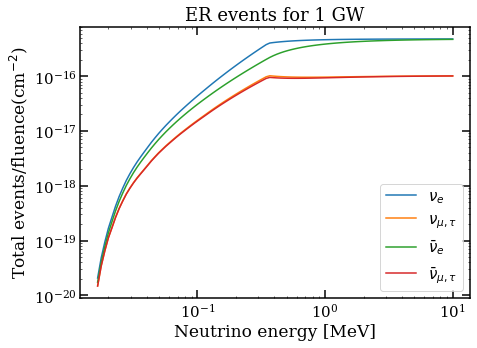

In [33]:
fig, ax = plt.subplots(1, 1, figsize=(7,5))
plt.plot(Neutrino_Energy/1000, rate_nu_e, label=r"${\nu}_e$")
plt.plot(Neutrino_Energy/1000, rate_nu_mu_tau, label=r"${\nu}_{\mu, \tau}$")
plt.plot(Neutrino_Energy/1000, rate_anti_nu_e, label=r"$\bar{\nu}_e$")
plt.plot(Neutrino_Energy/1000, rate_anti_nu_mu_tau, label=r"$\bar{\nu}_{\mu, \tau}$")
plt.xscale("log")
plt.yscale("log")
ax.set_xlabel("Neutrino energy [MeV]")
ax.set_ylabel(r"Total events/fluence(cm$^{-2}$)")
ax.set_title("ER events for 1 GW")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
#for i in range(0,np.shape(Xe.shells)[0]):
#    plt.axvline(min_Enu(Xe.shells[i][1])/1000) #in keV
#plt.axvline(Neutrino_Energy[17]/1000)
#plt.xlim(0.02,0.5)
plt.legend()
plt.show()

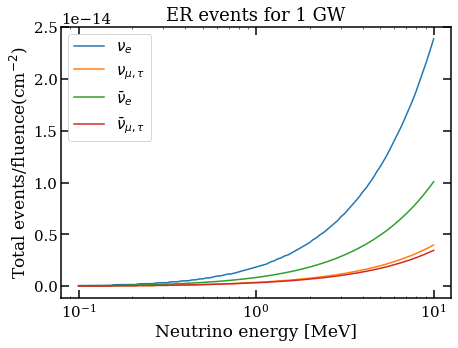

In [258]:
#If no upper limit
Es = np.linspace(0, 100, 251)

fig, ax = plt.subplots(1, 1, figsize=(7,5))
for neu in neutrinos:    
    plt.plot(Neutrino_Energy/1000, calc_rate_Ev(Es, accept_ER, neu, fm_ER), label=neu['label'])
plt.xscale("log")
ax.set_xlabel("Neutrino energy [MeV]")
ax.set_ylabel(r"Total events/fluence(cm$^{-2}$)")
ax.set_title("ER events for 1 GW")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
plt.legend()
plt.show()

# Set constraints

In [34]:
ul_nu_e = 2.3/rate_nu_e
ul_nu_x = 2.3/rate_nu_mu_tau
ul_anti_nu_e = 2.3/rate_anti_nu_e
ul_anti_nu_x = 2.3/rate_anti_nu_mu_tau

In [64]:
df = pd.DataFrame(list(zip(Neutrino_Energy/1000, ul_nu_e, ul_nu_x, ul_anti_nu_e, ul_anti_nu_x)))
np.savetxt('ER_lul_nu_e'imits.csv', df, delimiter=',')

SyntaxError: invalid syntax (<ipython-input-64-c8c377244600>, line 2)

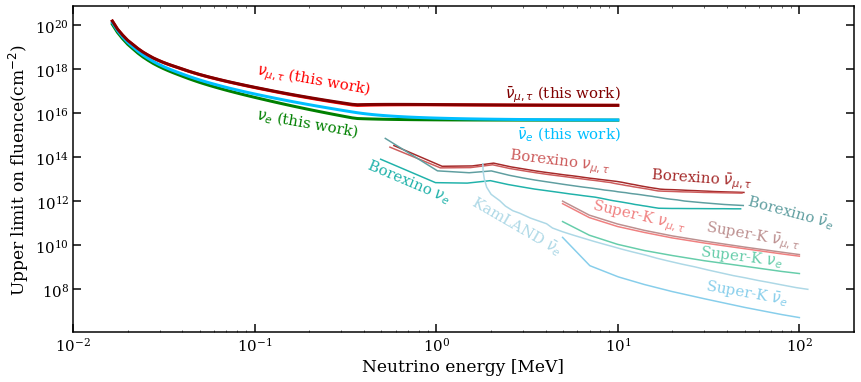

In [35]:
fig, ax = plt.subplots(1, 1, figsize=(14,6))
Anti_neutrinio_x = pd.read_csv('Anti_neutrino_x.csv')
neutrinio_x = pd.read_csv('neutrino_x.csv')
Anti_neutrinio_e = pd.read_csv('anti_neutrino_e.csv')
neutrinio_e = pd.read_csv('neutrino_e.csv')
Kamland = pd.read_csv('Kamland_e.csv')

Borexino_anti_neutrinio_e = pd.read_csv('Borexino_anti_neutrino_e.csv')
Borexino_neutrinio_e = pd.read_csv('Borexino_neutrino_e.csv')
Borexino_anti_neutrinio_x = pd.read_csv('Borexino_anti_neutrino_x.csv')
Borexino_neutrinio_x = pd.read_csv('Borexino_neutrino_x.csv')


plt.plot(Anti_neutrinio_x['Energy'], Anti_neutrinio_x['fluence'], color="rosybrown", label=r"Super-K $\bar{\nu}_{\mu,\tau}$")
plt.text(30, 8e9, r"Super-K $\bar{\nu}_{\mu,\tau}$", color="rosybrown", rotation = -10)

plt.plot(Borexino_anti_neutrinio_x['Energy'], Borexino_anti_neutrinio_x['fluence'], label=r"Super-K $\bar{\nu}_e$", color="brown")
plt.text(15, 5e12, r"Borexino $\bar{\nu}_{\mu,\tau}$", color="brown", rotation = -4)


plt.plot(neutrinio_x['Energy'], neutrinio_x['fluence'], label=r"Super-K ${\nu}_{\mu,\tau}$", color="lightcoral")
plt.text(7, 5*1e10, r"Super-K ${\nu}_{\mu,\tau}$", color="lightcoral", rotation = -13)

plt.plot(Borexino_neutrinio_x['Energy'], Borexino_neutrinio_x['fluence'], label=r"Super-K $\bar{\nu}_e$", color="indianred")
plt.text(2.5, 2.5e13, r"Borexino ${\nu}_{\mu,\tau}$", color="indianred", rotation = -7)


plt.plot(neutrinio_e['Energy'], neutrinio_e['fluence'], label=r"Super-K ${\nu}_e$", color="mediumaquamarine")
plt.text(28, 1.2e9, r"Super-K ${\nu}_e$", color="mediumaquamarine", rotation = -7)

plt.plot(Anti_neutrinio_e['Energy'], Anti_neutrinio_e['fluence'], label=r"Super-K $\bar{\nu}_e$", color="skyblue")
plt.text(30, 2e7, r"Super-K $\bar{\nu}_e$", color="skyblue", rotation = -10)

plt.plot(Borexino_anti_neutrinio_e['Energy'], Borexino_anti_neutrinio_e['fluence'], label=r"Super-K $\bar{\nu}_e$", color="cadetblue")
plt.text(50, 6e10, r"Borexino $\bar{\nu}_e$", color="cadetblue", rotation = -15)


plt.plot(Borexino_neutrinio_e['Energy'], Borexino_neutrinio_e['fluence'], color="lightseagreen")
plt.text(0.4, 9e11, r"Borexino ${\nu}_e$", color="lightseagreen", rotation = -23)


plt.plot(Kamland['Energy'], Kamland['fluence'], color="lightblue")
plt.text(1.5, 4e9, r"KamLAND $\bar{\nu}_e$", color="lightblue", rotation = -30)

plt.plot(Neutrino_Energy/1000, ul_nu_e,linewidth = 3, color="green")
plt.text(0.1, 9e14, r"${\nu}_e$ (this work)", color="green", rotation = -10)

plt.plot(Neutrino_Energy/1000, ul_nu_x,linewidth = 3, color="red")
plt.text(0.1, 8e16, r"${\nu}_{\mu, \tau}$ (this work)", color="red", rotation = -10)

plt.plot(Neutrino_Energy/1000, ul_anti_nu_e,linewidth = 3, color="deepskyblue" )
plt.text(2.8, 7e14, r"$\bar{\nu}_e$ (this work)", color="deepskyblue")

plt.plot(Neutrino_Energy/1000, ul_anti_nu_x,linewidth = 3, color="maroon" )
plt.text(2.4, 5*1e16, r"$\bar{\nu}_{\mu, \tau}$ (this work)", color="maroon")

#plt.ylim(1e6,1e19)
plt.xlim(0.01, 200)
plt.xscale("log")
plt.yscale("log")
ax.set_xlabel("Neutrino energy [MeV]")
ax.set_ylabel(r"Upper limit on fluence(cm$^{-2}$)")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
#plt.legend()
plt.show()

Checking if S2-only is useful

In [72]:
acc_data = pd.read_csv('/depot/darkmatter/data/jupyterhub/Riya/s2only_efficiency.csv')
accept = acc_data['Efficiency']*0.7 #because 30% of data is used for training
energy_S2only = acc_data['Energy'] 
accept_S2only = interp1d(energy_S2only, accept, bounds_error=False, fill_value=0, kind='linear')

In [75]:
fm_S2only = 2.004

In [76]:
plt.plot(Neutrino_Energy/1000, calc_rate_Ev(energy_S2only, accept_S2only, fm_S2only), label="S2only")
#plt.plot(Neutrino_Energy/1000, calc_rate_Ev(Es, accept_ER, fm_3fold), label="ER")
plt.show()

TypeError: calc_rate_Ev() missing 1 required positional argument: 'fm'

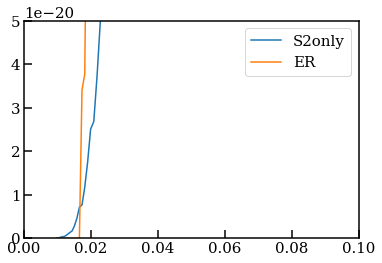

In [86]:
Neutrino_Energy = np.logspace(-2, 0, 101)*1000
plt.plot(Neutrino_Energy/1000, calc_rate_Ev(energy_S2only, accept_S2only, neutrino_e, fm_S2only), label="S2only")
plt.plot(Neutrino_Energy/1000, calc_rate_Ev(energy_ER, accept_ER, neutrino_e, fm_ER), label="ER")
plt.xlim(0, 0.1)
plt.ylim(0, 0.5*1e-19)
plt.legend()
plt.show()

not really!